# Final node embedding: clustering and cell content

**Role:** Analysis.

Load a saved GIN or FiLM checkpoint and characterize its final node embeddings across the validation population. This notebook restores the t-SNE, both marker-composition heatmaps, true/predicted baseline-subtracted curvature boxplots, and crypt-distance category plots from `clustering_analysis.ipynb` at commit `9ae3657`. Full-population views are always shown; optional accuracy-filtered views reproduce the historical within-cluster error filter.

The scaler, PCA and GMM are fitted on sampled training embeddings, and validation cells are assigned without fitting to their targets. This retains the refactored training/validation separation; it does not reproduce the old validation-fitted atlas exactly. Cluster IDs remain ordered by mean predicted physical curvature on training cells, consistently across every figure. Independent checkpoints have unrelated embedding coordinates and are analyzed separately. Models, target transforms and the baseline are loaded, never retrained. All validation cells contribute to composition, curvature and distance summaries; only scatter plots are subsampled.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Analysis settings

Choose the input run or cached report and all analysis options here before model loading, inference or plotting. Derived paths and model-dependent defaults are resolved in the following cells; each checkpoint restores its saved data and transformations.

In [ ]:
import numpy as np
import torch

# Sampling and plot selection
TRAINING_NOTEBOOK = 'gin_depth_training'  # Folder under training_results containing the saved run.
MAX_FIT_CELLS = 30000  # Maximum training cells used to fit the embedding atlas.
MAX_PLOT_CELLS = 10000  # Maximum plotted validation CELLS, not organoids; None plots all validation cells.
SEED = 42  # Random seed for reproducible sampling or initialization.

# Input runs, data and destinations
TRAINING_RUN = None  # Set a run directory name; None selects only if exactly one exists.

# Model selection
MODEL_DEPTH = 2  # Message-passing layers; choose a depth saved in the training run.
MODEL_FOLD = 0  # Load exactly one saved fold, never combine independent embedding spaces.
MODEL_NAME = 'gin'  # gin or film; None requires a unique model family among the matches.
MODEL_SEED = None  # None requires a unique saved seed at this depth/fold; otherwise specify the seed.
HIDDEN_DIM = None  # None requires a unique saved width; otherwise specify it.
MODEL_KEY = None  # Optional exact checkpoint key overriding the depth/fold/family/seed/width selectors.

# Inference resources
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use CUDA when available, otherwise CPU.

# Embedding and clustering
N_CLUSTERS = 6  # Number of embedding clusters to fit.
PCA_DIM = 16  # PCA dimensions used before clustering; None keeps all.

# t-SNE display (subsampling affects scatter plots only)
TSNE_PERPLEXITY = 40.  # Reduced automatically for small validation samples.
TSNE_LEARNING_RATE = 'auto'  # Optimizer step size or 'auto'.
TSNE_N_ITER = 1000  # t-SNE optimization iterations (at least 250).
TSNE_SEED = 420  # Reproducible cluster-stratified sampling and t-SNE coordinates.

# Optional historical accuracy-filtered views
SHOW_ACCURACY_FILTERED = True  # Also show the best-predicted fraction of each cluster, alongside all cells.
ERROR_FILTER_DROP_FRACTION = .50  # Drop this fraction of largest squared errors independently per cluster.
ERROR_FILTER_MIN_RETAINED_PER_CLUSTER = 1  # Keep at least this many cells from each nonempty cluster.

# Curvature display
SHOW_BOX_OUTLIERS = False  # Show individual outliers beyond boxplot whiskers.

# Distance to the nearest detected crypt bottom
DCRYPT_FIELD = 'd_crypts_graph'  # Node-wise distances from saved raw graph metadata.
DCRYPT_CRYPT_MAX = .7  # Distance below this value is in the crypt-distance category.
DCRYPT_NECK_MAX = 1.2  # Upper limit of the intermediate/neck-distance category.

## Select a saved model

Select one checkpoint/fold; independent models have unrelated embedding coordinates and are not concatenated. Both ordinary GIN and FiLM are supported, including full or exclusive fates. By default every validation cell is included, so cluster marker fractions describe center cells rather than selected LGR5 neighborhoods.

Set `MODEL_DEPTH` and `MODEL_FOLD` near the top to choose exactly one checkpoint; optional family/seed/width selectors resolve larger scans. `MODEL_KEY` is an explicit override, normally left as `None`. The resolved key, depth, fold and seed are printed before extraction. Only this model's validation fold is summarized; the training split fits the atlas. Displayed dots represent cells. `MAX_PLOT_CELLS` limits only the scatter sample, and `None` plots all validation cells. Missing or ambiguous model choices raise an error instead of silently choosing the first record.


In [ ]:
import json, copy
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.artifacts.runs import AnalysisRun
from src.analysis.metrics.evaluation import prediction_table
from src.artifacts.paths import resolve_training_run
RUN_DIR = resolve_training_run(ROOT, TRAINING_NOTEBOOK, TRAINING_RUN)  # Also accepts an explicit historical path.
run = AnalysisRun(RUN_DIR)
display(run.records)

# Saved model selection: one depth, one fold and one checkpoint.
if MODEL_KEY is None:
    if not isinstance(MODEL_DEPTH,int) or isinstance(MODEL_DEPTH,bool) or MODEL_DEPTH<0:
        raise ValueError('MODEL_DEPTH must be a nonnegative integer.')
    if not isinstance(MODEL_FOLD,int) or isinstance(MODEL_FOLD,bool) or MODEL_FOLD<0:
        raise ValueError('MODEL_FOLD must be a nonnegative integer.')
    candidates = run.records[(run.records.depth==MODEL_DEPTH)&(run.records.fold==MODEL_FOLD)].copy()
    for column,value in [('name',MODEL_NAME),('seed',MODEL_SEED),('hidden_dim',HIDDEN_DIM)]:
        if value is None:
            continue
        if column in candidates:
            candidates = candidates[candidates[column]==value]
        elif column=='hidden_dim' and run.legacy is not None:
            if run.legacy.settings['HIDDEN_DIM']!=value:
                candidates = candidates.iloc[:0]
        else:
            raise ValueError(f'The saved catalog lacks selection field {column}.')
    if len(candidates)!=1:
        raise ValueError(f'Select exactly one checkpoint at depth={MODEL_DEPTH}, fold={MODEL_FOLD}. '
            f'Matches: {candidates.key.tolist()}. Adjust MODEL_NAME, MODEL_SEED or HIDDEN_DIM, '
            'or provide MODEL_KEY from the displayed catalog.')
    selected_record = candidates.iloc[0]
else:
    candidates = run.records[run.records.key==MODEL_KEY]
    if len(candidates)!=1:
        raise ValueError(f'MODEL_KEY must identify one saved checkpoint: {MODEL_KEY}')
    selected_record = candidates.iloc[0]
# Do not overwrite MODEL_KEY: changing MODEL_DEPTH then rerunning this cell must
# reselect using the controls rather than accidentally pinning the old key.
SELECTED_MODEL_KEY = str(selected_record.key)
print(f'Loaded checkpoint: {SELECTED_MODEL_KEY}')
print(f"Model: {selected_record['name']}; depth: {selected_record.depth}; fold: {selected_record.fold}; seed: {selected_record.seed}")
if int(selected_record.depth)==0:
    print('Depth 0 has no neighbor aggregation. Repeated fate inputs can yield identical local embeddings.')

# Inference resources
selection = run.select(SELECTED_MODEL_KEY, device=DEVICE)
model = selection['model']
marker_names = selection['marker_names']
g_train, g_val = selection['groups']['train'], selection['groups']['val']
OUTPUT_DIR = RUN_DIR/'analysis'/'clustering'/SELECTED_MODEL_KEY  # Directory for this analysis’s tables and figures.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
population_summary = pd.DataFrame([dict(split=role,organoids=len(graphs),cells=sum(len(g.x) for g in graphs))
    for role,graphs in [('training (atlas fitting)',g_train),('validation (analysis)',g_val)]])
display(population_summary)
print('Validation cells are encoded in full; MAX_PLOT_CELLS caps only the scatter display.')


,key,name,subset,signal,depth,hidden_dim,fold,seed,bundle,input_bundle
0,gin_all_intact_d0_h128_f0_s42,gin,all,intact,0,128,0,42,models/gin_all_intact_d0_h128_f0_s42,inputs/fold_0_all_intact
1,gin_all_intact_d1_h128_f0_s42,gin,all,intact,1,128,0,42,models/gin_all_intact_d1_h128_f0_s42,inputs/fold_0_all_intact
2,gin_all_intact_d2_h128_f0_s42,gin,all,intact,2,128,0,42,models/gin_all_intact_d2_h128_f0_s42,inputs/fold_0_all_intact
3,gin_all_intact_d3_h128_f0_s42,gin,all,intact,3,128,0,42,models/gin_all_intact_d3_h128_f0_s42,inputs/fold_0_all_intact
4,gin_all_intact_d4_h128_f0_s42,gin,all,intact,4,128,0,42,models/gin_all_intact_d4_h128_f0_s42,inputs/fold_0_all_intact
5,gin_all_intact_d0_h128_f1_s42,gin,all,intact,0,128,1,42,models/gin_all_intact_d0_h128_f1_s42,inputs/fold_1_all_intact
6,gin_all_intact_d1_h128_f1_s42,gin,all,intact,1,128,1,42,models/gin_all_intact_d1_h128_f1_s42,inputs/fold_1_all_intact
7,gin_all_intact_d2_h128_f1_s42,gin,all,intact,2,128,1,42,models/gin_all_intact_d2_h128_f1_s42,inputs/fold_1_all_intact
8,gin_all_intact_d3_h128_f1_s42,gin,all,intact,3,128,1,42,models/gin_all_intact_d3_h128_f1_s42,inputs/fold_1_all_intact
9,gin_all_intact_d4_h128_f1_s42,gin,all,intact,4,128,1,42,models/gin_all_intact_d4_h128_f1_s42,inputs/fold_1_all_intact


Loaded checkpoint: gin_all_intact_d2_h128_f0_s42
Model: gin; depth: 2; fold: 0; seed: 42


/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


,split,organoids,cells
0,training (atlas fitting),695,340319
1,validation (analysis),174,79423


Validation cells are encoded in full; MAX_PLOT_CELLS caps only the scatter display.


## Extract final node representations

Extract representations before global features are concatenated to the prediction head. FiLM conditioning remains part of the representation. Fit a scaler, PCA and GMM on training cells; assign validation cells without fitting to their targets. Cluster numbers are then ordered by mean predicted physical curvature on training cells.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from src.analysis.embeddings.clustering import extract_node_embeddings

if N_CLUSTERS < 1 or MAX_FIT_CELLS < N_CLUSTERS:
    raise ValueError('Use a positive cluster count and enough fitting cells.')
train_repr = extract_node_embeddings(g_train, model, device=DEVICE)
val_repr = extract_node_embeddings(g_val, model, device=DEVICE)
rng = np.random.default_rng(SEED)
fit_ids = np.sort(rng.choice(len(train_repr.embeddings_local), min(MAX_FIT_CELLS,len(train_repr.embeddings_local)), replace=False))
scaler = StandardScaler().fit(train_repr.embeddings_local[fit_ids])
scaled_train = scaler.transform(train_repr.embeddings_local[fit_ids])
scaled_val = scaler.transform(val_repr.embeddings_local)
pca = None if PCA_DIM is None else PCA(n_components=min(PCA_DIM,len(fit_ids),scaled_train.shape[1]),random_state=SEED)
train_z = scaled_train if pca is None else pca.fit_transform(scaled_train)
val_z = scaled_val if pca is None else pca.transform(scaled_val)
gmm = GaussianMixture(N_CLUSTERS, random_state=SEED, reg_covar=1e-5).fit(train_z)
training_predictions = prediction_table(selection, role='train', device=DEVICE)
raw_labels = gmm.predict(train_z)
order = pd.DataFrame({'cluster':raw_labels,'curvature':training_predictions.y_pred.to_numpy()[fit_ids]}).groupby('cluster').curvature.mean().sort_values().index.tolist()
order += [c for c in range(N_CLUSTERS) if c not in order]
label_map = {c:i for i,c in enumerate(order)}
labels = np.array([label_map[c] for c in gmm.predict(val_z)])
predictions = prediction_table(selection, device=DEVICE).assign(cluster=labels)
display(predictions.groupby('cluster').agg(cells=('node','size'),organoids=('organoid_str','nunique'),measured_curvature=('y_true','mean'),predicted_curvature=('y_pred','mean')))
print('PCA explained variance:', pca.explained_variance_ratio_.sum() if pca is not None else 'PCA disabled')
# Verify node alignment before combining embeddings, targets and metadata.
assert np.array_equal(predictions.node.to_numpy(),val_repr.local_node_index)
assert np.array_equal(predictions.organoid_str.to_numpy(),np.asarray(val_repr.organoid_ids))
cluster_order = np.arange(N_CLUSTERS)
cluster_colors = plt.get_cmap('tab20',N_CLUSTERS)(cluster_order)

,cells,organoids,measured_curvature,predicted_curvature
cluster,,,,
0,13031,148,0.020134,0.024396
1,13426,152,0.021701,0.028382
2,13248,168,0.022445,0.027968
3,7317,147,0.024228,0.030160
4,13734,133,0.042242,0.043230
5,18667,166,0.063558,0.056709


PCA explained variance: 0.7758392


## Prepare residual curvature and full/filtered populations

Restore physical curvature first, then subtract the saved global baseline from both truth and prediction. This works whether or not the GNN was trained on residuals: residualization offsets are not substituted for baseline predictions when training used raw targets.

The optional historical filter retains the smallest squared errors within each cluster (50% by default). Cluster assignments and t-SNE coordinates do not change. Filtered panels describe this selected subset, not unbiased prediction quality; all-cell panels remain the primary population summaries.

In [ ]:
if 'baseline_prediction' not in predictions:
    saved_settings = selection.get('settings',run.settings)
    residualized = selection.get('residualized',saved_settings.get('residualize',
        saved_settings.get('SUBTRACT_CONSTANT_GLOBAL_BASELINE',False)))
    if not residualized:
        raise ValueError('This saved run lacks baseline predictions. Residual plots require a saved baseline; do not substitute zero offsets.')
    predictions['baseline_prediction'] = np.concatenate([
        np.broadcast_to(np.asarray(selection['baseline_offsets'][g.organoid_str]).reshape(-1),(len(g.x),))
        for g in g_val])
predictions['y_true_residual'] = predictions.y_true-predictions.baseline_prediction
predictions['y_pred_residual'] = predictions.y_pred-predictions.baseline_prediction
if not 0 <= ERROR_FILTER_DROP_FRACTION < 1 or ERROR_FILTER_MIN_RETAINED_PER_CLUSTER < 1:
    raise ValueError('Use a drop fraction in [0,1) and at least one retained cell per cluster.')
retained_mask = np.zeros(len(labels),dtype=bool)
for cluster in cluster_order:
    ids = np.flatnonzero(labels==cluster)
    keep = min(len(ids),max(ERROR_FILTER_MIN_RETAINED_PER_CLUSTER,int(np.ceil((1-ERROR_FILTER_DROP_FRACTION)*len(ids)))))
    errors = predictions.squared_error.to_numpy()[ids]
    retained_mask[ids[np.argsort(np.where(np.isfinite(errors),errors,np.inf),kind='stable')[:keep]]] = True
predictions['accuracy_retained'] = retained_mask
subsets = {'full':np.ones(len(labels),dtype=bool)}
if SHOW_ACCURACY_FILTERED:
    subsets['filtered'] = retained_mask
subset_labels = {'full':'all validation cells','filtered':'accuracy-filtered validation cells'}
display(predictions.groupby('cluster').agg(cells=('node','size'),retained=('accuracy_retained','sum'),
    true_residual=('y_true_residual','mean'),predicted_residual=('y_pred_residual','mean')))

,cells,retained,true_residual,predicted_residual
cluster,,,,
0,13031,6516,-0.015521,-0.011259
1,13426,6713,-0.016324,-0.009644
2,13248,6624,-0.018616,-0.013093
3,7317,3659,-0.008181,-0.002250
4,13734,6867,0.004799,0.005788
5,18667,9334,0.027926,0.021077


## t-SNE visualization of clusters

Draw a cluster-stratified sample, fit t-SNE once, and reuse the same coordinates and axis limits in all-cell and accuracy-filtered panels. Cluster colors and labels are identical throughout the notebook. t-SNE is only a display: the GMM assignments come from the higher-dimensional representation. A companion PCA panel preserves the existing overview.

,population,analyzed_cells,analyzed_organoids,plotted_cells,plotted_organoids
0,all validation cells,79423,174,10000,174
1,accuracy-filtered validation cells,39713,174,5024,174


10,000 plotted cells have 9,398 distinct final embedding vectors; points can overlap.


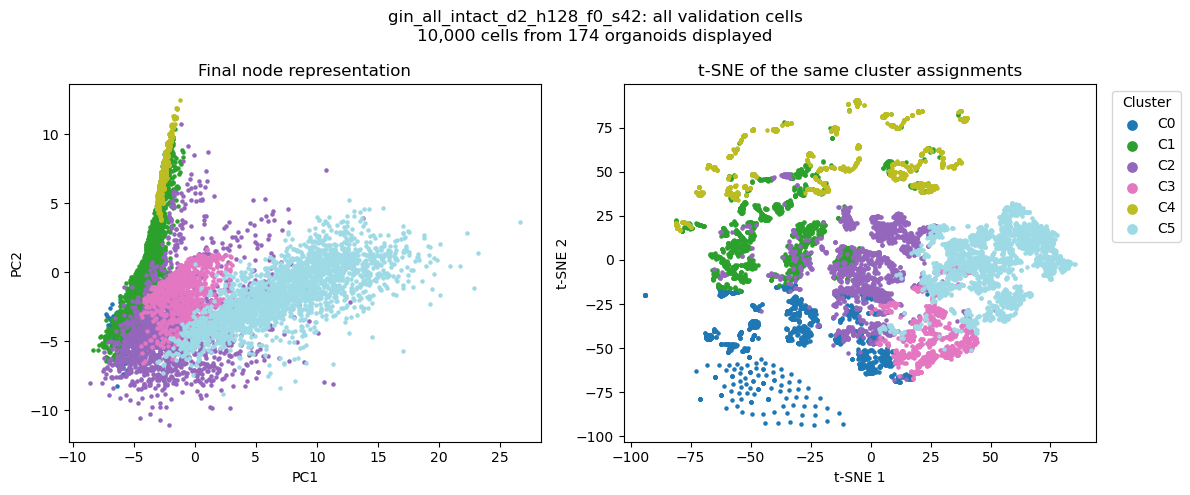

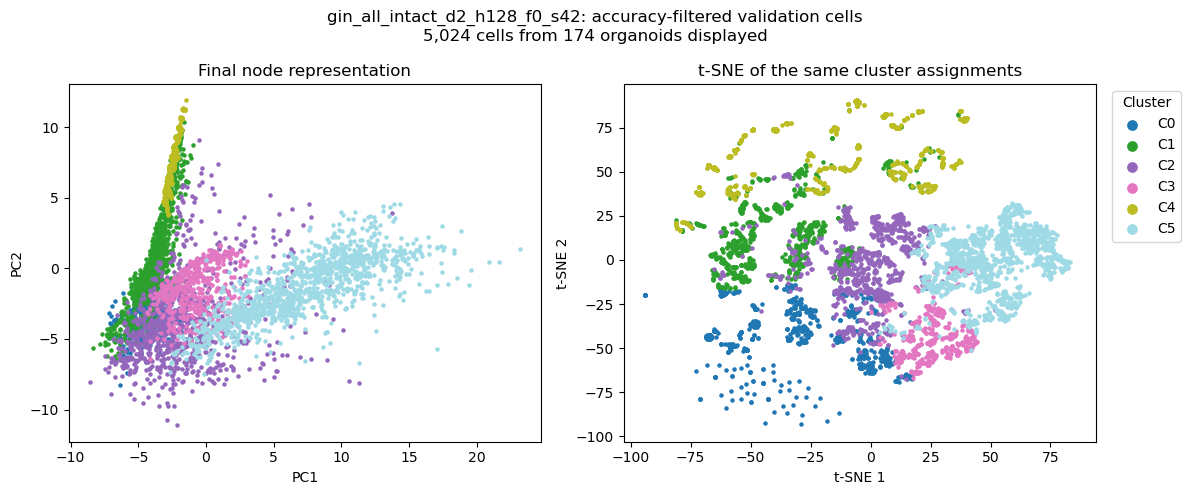

In [ ]:
def stratified_plot_indices(labels,max_points,seed):
    if max_points is None or len(labels)<=max_points:
        return np.arange(len(labels))
    clusters,counts = np.unique(labels,return_counts=True)
    if max_points<len(clusters):
        raise ValueError('MAX_PLOT_CELLS must include at least one point per occupied cluster.')
    targets = np.maximum(1,np.floor(counts/counts.sum()*max_points).astype(int))
    while targets.sum()>max_points:
        candidates = np.flatnonzero(targets>1)
        targets[candidates[np.argmax(targets[candidates])]] -= 1
    while targets.sum()<max_points:
        targets[np.argmax(counts-targets)] += 1
    draw = np.random.default_rng(seed)
    return np.sort(np.concatenate([draw.choice(np.flatnonzero(labels==c),int(t),replace=False)
        for c,t in zip(clusters,targets)]))

plot_ids = stratified_plot_indices(labels,MAX_PLOT_CELLS,TSNE_SEED)
plot_support = []
for subset,mask in subsets.items():
    displayed = plot_ids[mask[plot_ids]]
    plot_support.append(dict(population=subset_labels[subset],
        analyzed_cells=int(mask.sum()),analyzed_organoids=predictions.loc[mask,'organoid_str'].nunique(),
        plotted_cells=len(displayed),plotted_organoids=predictions.iloc[displayed].organoid_str.nunique()))
plot_support = pd.DataFrame(plot_support)
display(plot_support)
plot_support.to_csv(OUTPUT_DIR/'scatter_population_counts.csv',index=False)
unique_embeddings = np.unique(val_repr.embeddings_local[plot_ids],axis=0).shape[0]
print(f'{len(plot_ids):,} plotted cells have {unique_embeddings:,} distinct final embedding vectors; points can overlap.')
if len(plot_ids)<2:
    raise ValueError('t-SNE needs at least two validation cells.')
xy = TSNE(n_components=2,perplexity=min(TSNE_PERPLEXITY,max(1.,(len(plot_ids)-1)/3)),
    learning_rate=TSNE_LEARNING_RATE,max_iter=TSNE_N_ITER,random_state=TSNE_SEED,
    init='pca' if val_z.shape[1]>=2 else 'random').fit_transform(val_z[plot_ids])
for subset,mask in subsets.items():
    fig,axes = plt.subplots(1,2,figsize=(12,5))
    for cluster in cluster_order:
        selected = (labels[plot_ids]==cluster)&mask[plot_ids]
        ids = plot_ids[selected]
        axes[0].scatter(val_z[ids,0],val_z[ids,1] if val_z.shape[1]>1 else np.zeros(len(ids)),
            s=5,color=cluster_colors[cluster],label=f'C{cluster}',rasterized=True)
        axes[1].scatter(xy[selected,0],xy[selected,1],s=5,color=cluster_colors[cluster],
            label=f'C{cluster}',rasterized=True)
    for dim in (0,1):
        low,high = xy[:,dim].min(),xy[:,dim].max()
        margin = max((high-low)*.05,1e-6)
        (axes[1].set_xlim if dim==0 else axes[1].set_ylim)(low-margin,high+margin)
    axes[0].set(xlabel='PC1' if pca is not None else 'Standardized feature 1',
        ylabel='PC2' if pca is not None else 'Standardized feature 2',title='Final node representation')
    axes[1].set(xlabel='t-SNE 1',ylabel='t-SNE 2',title='t-SNE of the same cluster assignments')
    axes[1].legend(title='Cluster',markerscale=3,bbox_to_anchor=(1.02,1),loc='upper left')
    shown = plot_ids[mask[plot_ids]]
    fig.suptitle(f'{SELECTED_MODEL_KEY}: {subset_labels[subset]}\n'
        f'{len(shown):,} cells from {predictions.iloc[shown].organoid_str.nunique()} organoids displayed')
    fig.tight_layout();fig.savefig(OUTPUT_DIR/f'tsne_clusters_{subset}.png',dpi=180,bbox_inches='tight');plt.show()
tsne_table = predictions.iloc[plot_ids][['organoid_str','node','cluster','accuracy_retained']].copy()
tsne_table['tsne_1'],tsne_table['tsne_2'] = xy[:,0],xy[:,1]
tsne_table.to_csv(OUTPUT_DIR/'tsne_coordinates.csv',index=False)

## Marker composition: both normalizations

The left heatmap is **P(marker positive | cluster)**: divide marker-positive cells in a cluster by all cells in that cluster. The right heatmap is **P(cluster | marker positive)**: divide by all cells positive for that marker in the displayed population, across every cluster. Thus right-hand columns sum to one when the marker is present. For filtered views, both denominators refer to the retained subset, as in the original notebook. Coexpression is retained; Unassigned means no positive fate marker. Absent markers or empty clusters are undefined, shown white.

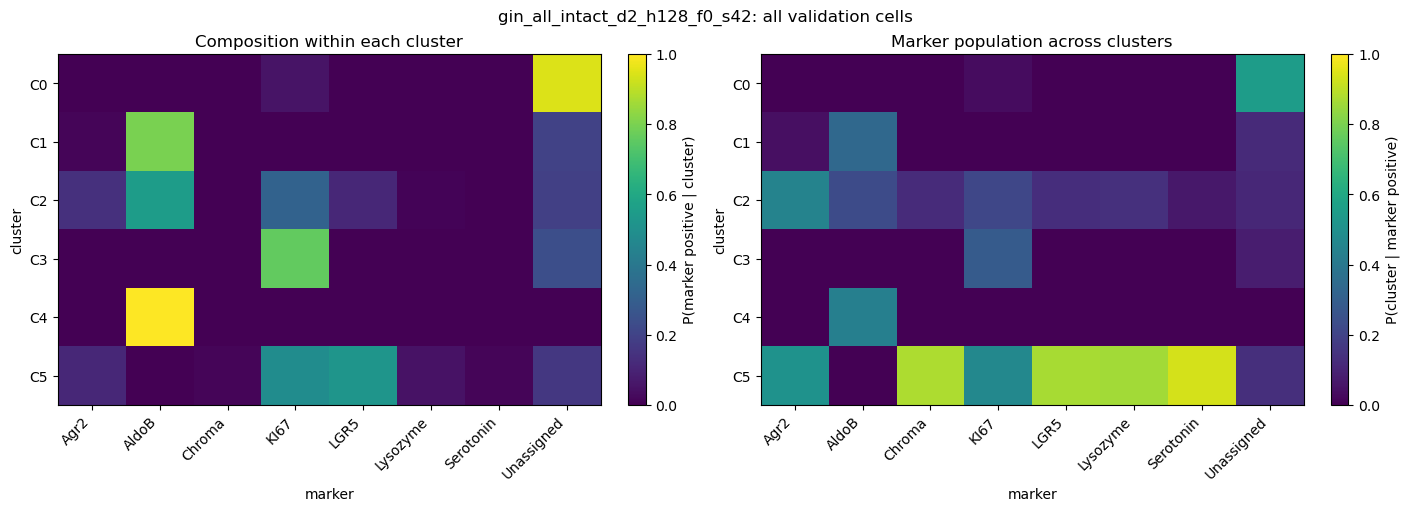

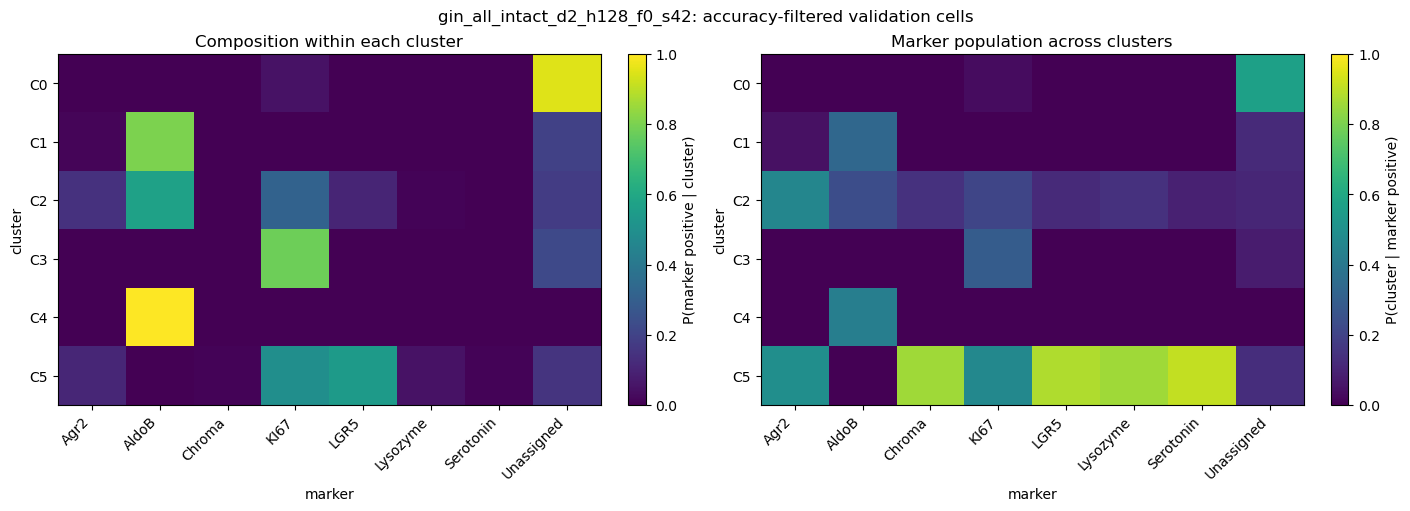

In [ ]:
from src.plotting.cluster_plots import plot_cluster_marker_heatmap
fates = val_repr.x_markers[:,:len(marker_names)]
marker_names_extended = [*marker_names,'Unassigned']
x_extended = np.c_[fates,(fates.sum(1)==0)]
marker_tables = {}
for subset,mask in subsets.items():
    marker_counts = pd.DataFrame([x_extended[mask&(labels==c)].sum(0) for c in cluster_order],
        index=pd.Index(cluster_order,name='cluster'),columns=marker_names_extended)
    sizes = pd.Series([np.sum(mask&(labels==c)) for c in cluster_order],index=cluster_order)
    within = marker_counts.div(sizes.replace(0,np.nan),axis=0)
    population = marker_counts.div(marker_counts.sum(0).replace(0,np.nan),axis=1)
    marker_tables[subset] = dict(counts=marker_counts,within=within,population=population)
    cmap = plt.get_cmap('viridis').copy();cmap.set_bad('white')
    fig,axes = plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
    for ax,table,title,label in [(axes[0],within,'Composition within each cluster','P(marker positive | cluster)'),
                               (axes[1],population,'Marker population across clusters','P(cluster | marker positive)')]:
        plot_cluster_marker_heatmap(table,marker_names_extended,ax=ax,title=title,
            colorbar_label=label,cmap=cmap,vmin=0,vmax=1)
    fig.suptitle(f'{SELECTED_MODEL_KEY}: {subset_labels[subset]}')
    fig.savefig(OUTPUT_DIR/f'marker_composition_{subset}.png',dpi=180,bbox_inches='tight');plt.show()
    for normalization,table in marker_tables[subset].items():
        table.to_csv(OUTPUT_DIR/f'marker_{normalization}_{subset}.csv')
content = marker_tables['full']['within']
content.to_csv(OUTPUT_DIR/'marker_content.csv')

## True and predicted residual curvature by cluster

Paired boxplots compare **true − saved baseline** and **predicted − saved baseline**, in physical curvature units. The saved baseline is subtracted exactly once even for residual-trained models, because `prediction_table` first reconstructs full curvature. Cluster order is fixed from the training predictions and is not reordered independently for these panels. Full and filtered panels share a vertical scale.

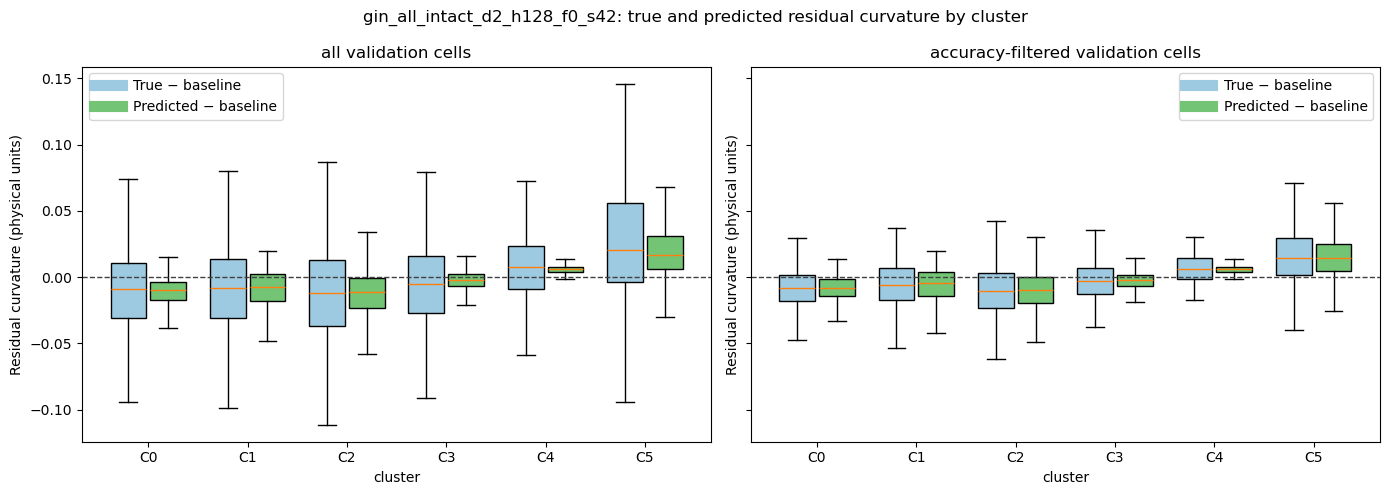

In [ ]:
from src.plotting.cluster_plots import plot_cluster_boxplots
fig,axes = plt.subplots(1,len(subsets),figsize=(7*len(subsets),5),squeeze=False,sharey=True)
for ax,(subset,mask) in zip(axes[0],subsets.items()):
    plot_cluster_boxplots([predictions.y_true_residual.to_numpy()[mask],predictions.y_pred_residual.to_numpy()[mask]],
        labels[mask],data_labels=['True − baseline','Predicted − baseline'],colors=['#9ecae1','#74c476'],
        cluster_order=cluster_order,show_outliers=SHOW_BOX_OUTLIERS,ax=ax,
        ylabel='Residual curvature (physical units)',title=subset_labels[subset])
    ax.axhline(0,color='.25',linestyle='--',linewidth=1)
fig.suptitle(f'{SELECTED_MODEL_KEY}: true and predicted residual curvature by cluster')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'cluster_residual_curvature.png',dpi=180,bbox_inches='tight');plt.show()

## Crypt-distance categories by cluster

Restore the original nearest-crypt distance bins from saved raw graph metadata, with an “All” population reference alongside each cluster. Distance below 0.7 is the crypt bin; 0.7–1.2 is the intermediate/neck-distance bin; above 1.2 is the villus-distance bin. Thresholds are configurable near the top. These are distance categories, not a circumference-qualified anatomical neck classification. Missing distances or undetected crypts stay in a separate category; they are not interpreted as villus. Small crypts may be undetected, especially at low N.

Finite crypt distances: 75201 / 79423 validation cells


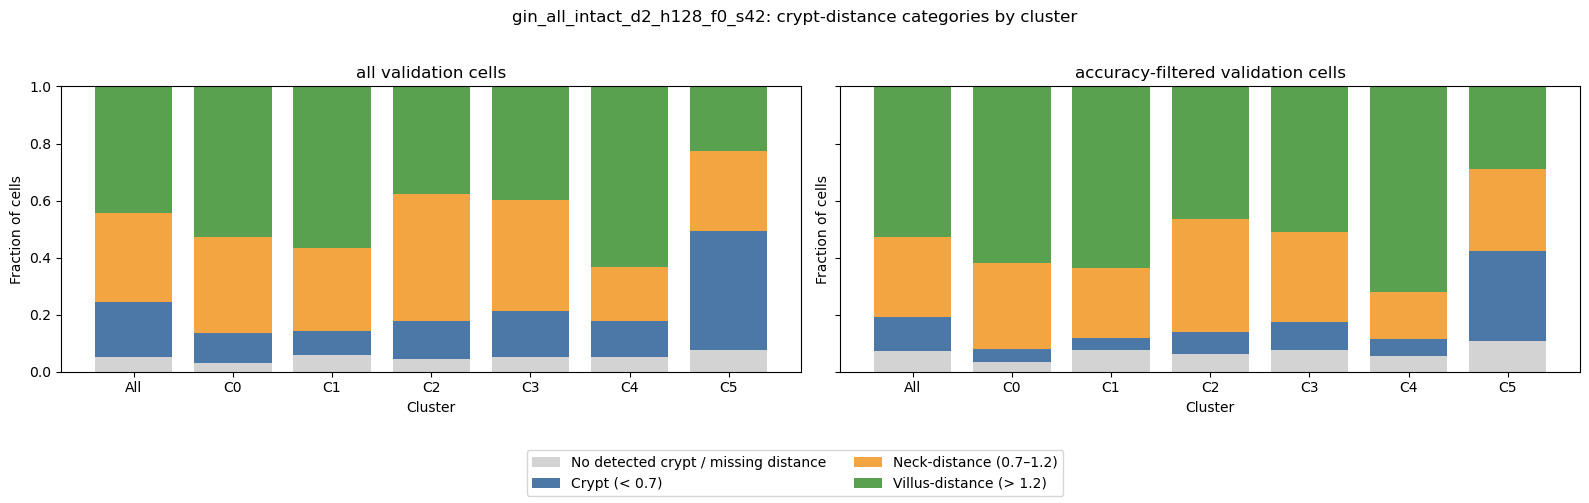

In [ ]:
from src.data.metadata import get_graph_metadata_value

def min_node_dcrypt(raw,n_nodes):
    if raw is None:
        return np.full(n_nodes,np.nan)
    if torch.is_tensor(raw):
        raw = raw.detach().cpu().numpy()
    values = np.asarray(raw,dtype=float)
    if values.size==0:
        return np.full(n_nodes,np.nan)
    if values.size==1:
        return np.full(n_nodes,float(values.reshape(-1)[0]))
    axes = [axis for axis,size in enumerate(values.shape) if size==n_nodes]
    if len(axes)!=1:
        raise ValueError(f'Cannot unambiguously align crypt distances {values.shape} with {n_nodes} cells.')
    values = np.moveaxis(values,axes[0],0).reshape(n_nodes,-1)
    finite = np.isfinite(values)
    nearest = np.where(finite,values,np.inf).min(1)
    nearest[~finite.any(1)] = np.nan
    return nearest

if not 0<DCRYPT_CRYPT_MAX<DCRYPT_NECK_MAX:
    raise ValueError('Crypt-distance boundaries must be positive and increasing.')
dcrypt_values = np.concatenate([min_node_dcrypt(get_graph_metadata_value(
    selection['raw_graphs'][g.organoid_str],DCRYPT_FIELD,default=None),len(g.x)) for g in g_val])
category_names = ['No detected crypt / missing distance',f'Crypt (< {DCRYPT_CRYPT_MAX:g})',
    f'Neck-distance ({DCRYPT_CRYPT_MAX:g}–{DCRYPT_NECK_MAX:g})',f'Villus-distance (> {DCRYPT_NECK_MAX:g})']
categories = np.select([~np.isfinite(dcrypt_values),dcrypt_values<DCRYPT_CRYPT_MAX,dcrypt_values<=DCRYPT_NECK_MAX],
    category_names[:3],default=category_names[3])
predictions['dcrypt'],predictions['dcrypt_category'] = dcrypt_values,categories
print(f'Finite crypt distances: {np.isfinite(dcrypt_values).sum()} / {len(dcrypt_values)} validation cells')
fig,axes = plt.subplots(1,len(subsets),figsize=(8*len(subsets),5),squeeze=False,sharey=True)
dcrypt_tables = {}
for ax,(subset,mask) in zip(axes[0],subsets.items()):
    masks = [mask,*[mask&(labels==c) for c in cluster_order]]
    table = pd.DataFrame([[np.mean(categories[m]==cat) if m.any() else np.nan for cat in category_names] for m in masks],
        index=['All',*[f'C{c}' for c in cluster_order]],columns=category_names)
    dcrypt_tables[subset] = table
    bottom = np.zeros(len(table))
    for category,color in zip(category_names,['lightgray','#4C78A8','#F2A541','#59A14F']):
        values = table[category].to_numpy()
        ax.bar(np.arange(len(table)),values,bottom=bottom,color=color,label=category,width=.78)
        bottom += np.nan_to_num(values)
    ax.set(xticks=np.arange(len(table)),xticklabels=table.index,ylim=(0,1),xlabel='Cluster',ylabel='Fraction of cells',title=subset_labels[subset])
    table.to_csv(OUTPUT_DIR/f'dcrypt_category_fractions_{subset}.csv',index_label='group')
handles,legend_labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,legend_labels,loc='lower center',ncol=2)
fig.suptitle(f'{SELECTED_MODEL_KEY}: crypt-distance categories by cluster')
fig.tight_layout(rect=(0,.14,1,.96));fig.savefig(OUTPUT_DIR/'crypt_distance_categories.png',dpi=180,bbox_inches='tight');plt.show()

## Save the atlas, cell annotations and analysis settings

Save the fitted representation atlas, model key, fixed cluster-order mapping, complete annotated validation population, and plot settings. These files accompany the figures and composition/distance tables above. No training weights or train/validation splits are changed.

In [ ]:
import pickle
predictions.to_csv(OUTPUT_DIR/'cells.csv.gz',index=False)
with (OUTPUT_DIR/'atlas.pkl').open('wb') as handle:
    pickle.dump(dict(scaler=scaler,pca=pca,gmm=gmm,label_map=label_map,model_key=SELECTED_MODEL_KEY),handle)
analysis_settings = dict(training_run=str(RUN_DIR),model_key=SELECTED_MODEL_KEY,n_clusters=N_CLUSTERS,pca_dim=PCA_DIM,
    model_depth=int(selected_record.depth),model_fold=int(selected_record.fold),
    model_seed=int(selected_record.seed),model_name=str(selected_record['name']),
    max_fit_cells=MAX_FIT_CELLS,max_plot_cells=MAX_PLOT_CELLS,seed=SEED,
    cluster_order='ascending mean predicted physical curvature on fitted training cells',
    tsne_perplexity=TSNE_PERPLEXITY,tsne_learning_rate=TSNE_LEARNING_RATE,tsne_iterations=TSNE_N_ITER,tsne_seed=TSNE_SEED,
    show_accuracy_filtered=SHOW_ACCURACY_FILTERED,error_filter_drop_fraction=ERROR_FILTER_DROP_FRACTION,
    error_filter_min_retained=ERROR_FILTER_MIN_RETAINED_PER_CLUSTER,show_box_outliers=SHOW_BOX_OUTLIERS,
    dcrypt_field=DCRYPT_FIELD,dcrypt_crypt_max=DCRYPT_CRYPT_MAX,dcrypt_neck_max=DCRYPT_NECK_MAX)
(OUTPUT_DIR/'analysis_settings.json').write_text(json.dumps(analysis_settings,indent=2))
print('Figures, tables and atlas saved to:',OUTPUT_DIR)

Figures, tables and atlas saved to: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/scMultiplexpaper_20260918_161107/analysis/clustering/gin_all_intact_d2_h128_f0_s42
